# mechanism_viewer example

## Using imputation to detect distribution differences

This notebook contains examples in how to use the module `viewer_imputation.py`. The module has 2 function: `scatterplot_imputation_comparison()` and `plot_imputation_distribution()`. Both functions, execute an imputation model to generate values for missing data in a specific missing column, depending on its data type. The imputed data can then be used to find the hidden missing patterns, when comparing to other observed columns.

Furthermore, for reproducible experiments, the functions can use `DEFAULT_RANDOM_STATE`. Otherwise, the user can change the seed in the parameter `random_state`.

### 1. Generate synthetic datasets with missing values

For this notebook, two datasets will be used. The first and main dataset contains one complete column, and three columns with different missingness patterns and different data types. Meanwhile, the second dataset has 2 complete columns and one categorical non-numeric column, which will be useful for `plot_imputation_distribution()`

In [1]:
from mechanism_viewer import generate_dataset_with_missing_data, ColType

data = generate_dataset_with_missing_data(200, [ColType.CONTINUOUS, ColType.CONTINUOUS, ColType.DISCRETE,
                                                ColType.BINARY], 1, ["MAR", "MCAR", "MNAR"], [0.20, 0.20, 0.20])

display(data.head(10))

,Col1,Col2,Col3,Col4
0,0.496714,0.357787,2,1
1,-0.138264,0.560785,10,1
2,0.647689,1.083051,6,0
3,1.523030,NaN,9,0
4,-0.234153,-1.377669,4,1
5,-0.234137,-0.937825,<NA>,1
6,1.579213,NaN,6,1
7,0.767435,NaN,8,0
8,-0.469474,0.515048,6,1
9,0.542560,3.852731,2,1


In [2]:
import pandas as pd

data_categ_non_num = pd.DataFrame({"age_col": [23, 35, 29, 41, 52, 31, 47, 28, 39, 44],
                                 "income_col": [32000, 58000, 41000, 72000, 90000, 47000, 81000, 39000, 65000, 76000],
                                 "block_col": ["A", "B", "A", None, "C", "B", None, "A", "C", None]})

display(data_categ_non_num.head(10))

,age_col,income_col,block_col
0,23,32000,A
1,35,58000,B
2,29,41000,A
3,41,72000,None
4,52,90000,C
5,31,47000,B
6,47,81000,None
7,28,39000,A
8,39,65000,C
9,44,76000,None


### 2) Plot imputation with `scatterplot_imputation_comparison()`

The function `scatterplot_imputation_comparison()` enables the user to view what happens to the missing column after having its misssing values imputed. The function plots a scatterplot that uses an extra column, `column_name`, to visualize the data points in 2 dimensions, making it easier to detect possible missing data mechanism of the missing column.

In the next example, the complete column, Col1, will be used as the column to compare the differences before and after imputation of the missing column, Col2. It is important to note that `column_name` is not required to be complete, although a warning will be displayed, as scatterplot will not display data points with missing values.

The imputation model to be used in `missing_col` is determined by `missing_col_type`. In other words, the function selects the model that is best suited for the data type of the missing column. However, the default value of the parameter, `missing_col_type="normal"`, can be used for a MICE model imputation. 

Moreover, the imputation of `missing_col` uses every complete column in the given dataset. Thus, if `column_name` is not complete, then that column will not be used to impute values in the missing column.

In addition, the function returns a `(figure, axis)` tuple, so that the user can adapt the plot to their wish. In addition, by setting `display_plot=True`, the function will also display the plot inside the notebook.

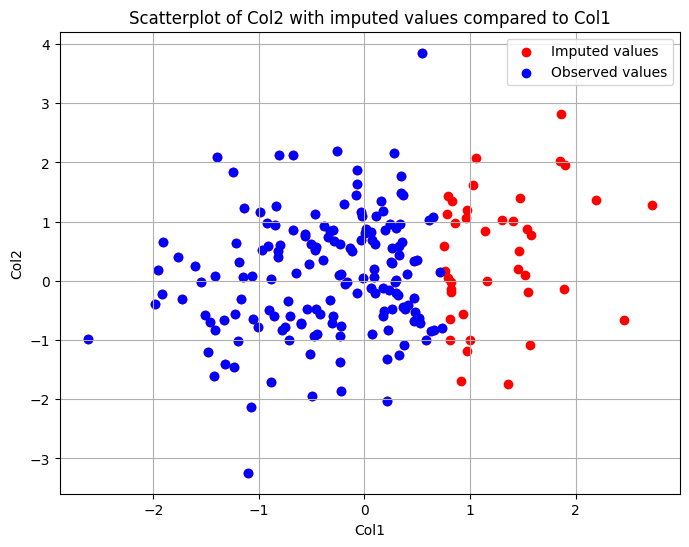

In [3]:
from mechanism_viewer import scatterplot_imputation_comparison, DEFAULT_RANDOM_STATE

fig_scatter, ax_scatter = scatterplot_imputation_comparison(data, column_name="Col1",
                                                            missing_col="Col2", missing_col_type=ColType.CONTINUOUS,
                                                            random_state=DEFAULT_RANDOM_STATE, display_plot=True)

The plot suggests that the data points with imputed values in Col2 tend to have high values in Col1. This result may imply that Col2 has a MAR missing data mechanism, with its missing values dependent on Col1.

For the next example, the `missing_col` will be Col3, which is of discrete data type.

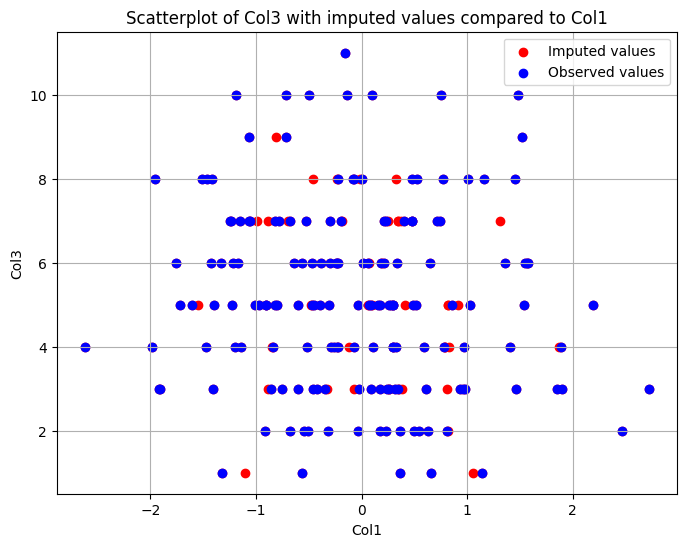

In [4]:
fig_scatter_2, ax_scatter_2 = scatterplot_imputation_comparison(data, column_name="Col1",
                                                            missing_col="Col3", missing_col_type=ColType.DISCRETE,
                                                            random_state=DEFAULT_RANDOM_STATE, display_plot=True)

The result indicates that Col3 has its imputed values scattered around the plot, suggesting no relationship between Col1 for its missing values.

For the final example of `scatterplot_imputation_comparison()`, the `column_name` will be a missing column. As a consequence, warnings will be shown.

C:\Users\Utiizador\AppData\Local\Temp\ipykernel_18360\2069629897.py:1: UserWarning: Col3 is not a complete column in the original dataset. Thus, it was not used for the imputation process. 
  fig_scatter_2, ax_scatter_2 = scatterplot_imputation_comparison(data, column_name="Col3",
C:\Users\Utiizador\AppData\Local\Temp\ipykernel_18360\2069629897.py:1: UserWarning: Some data points were not plotted due to existence of a missing value in either Col3 or Col2. Total dropped after imputation: 40.
  fig_scatter_2, ax_scatter_2 = scatterplot_imputation_comparison(data, column_name="Col3",


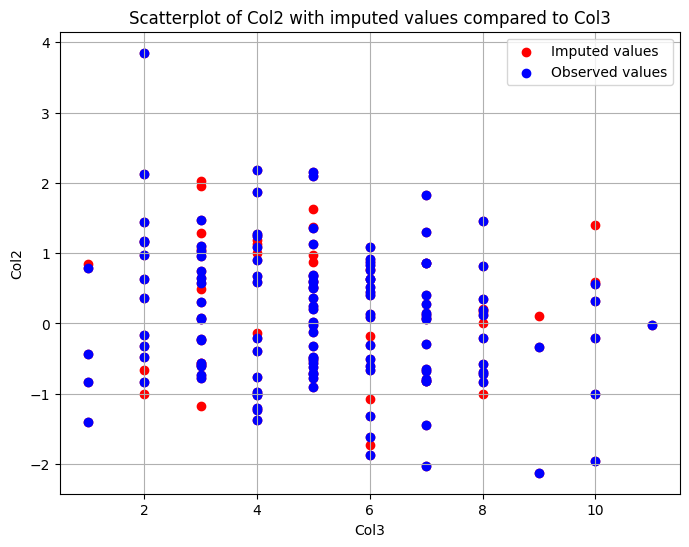

In [5]:
fig_scatter_2, ax_scatter_2 = scatterplot_imputation_comparison(data, column_name="Col3",
                                                            missing_col="Col2", missing_col_type=ColType.CONTINUOUS,
                                                            random_state=DEFAULT_RANDOM_STATE, display_plot=True)

As evident by the plot, Col2 does not depend in Col3 for its missingness patterns.

### 3) Plot the consequences of imputation using `plot_imputation_distribution()`

The function `plot_imputation_distribution()` visualizes the distribution of `missing_col` before and after the imputation process.  

The function returns a tuple `(fig_imput_dist, ax_imput_dist, imputed_df)`, which includes the plot ready for display, and a new dataset containing the columns used for imputation, along with `missing_col` populated with its imputed values.

> This does not offer much aid in figuring the data missing mechanism. It only serves the purpose of showcasing each imputation model working for the correct data type.

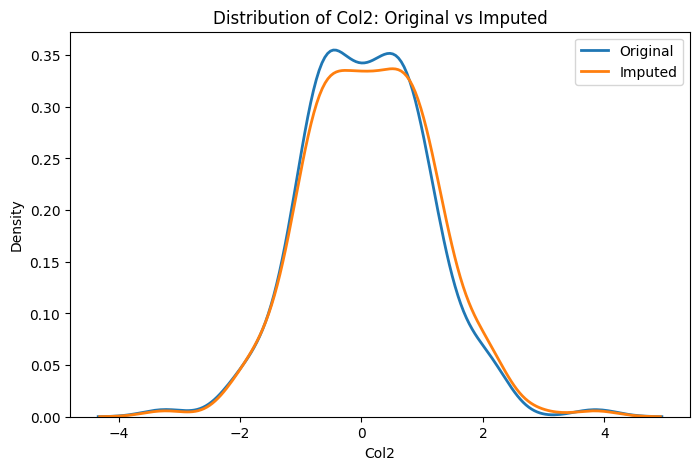

In [6]:
from mechanism_viewer import plot_imputation_distribution

# Distribution of Col2, with type ColType.CONTINUOUS

fig_dist, ax_dist, imputed_df = plot_imputation_distribution(data, missing_col="Col2", missing_col_type=ColType.CONTINUOUS,
                                                             random_state=DEFAULT_RANDOM_STATE, display_plot=True)

This example imputes a binary column, Col4, and plots its distribution.

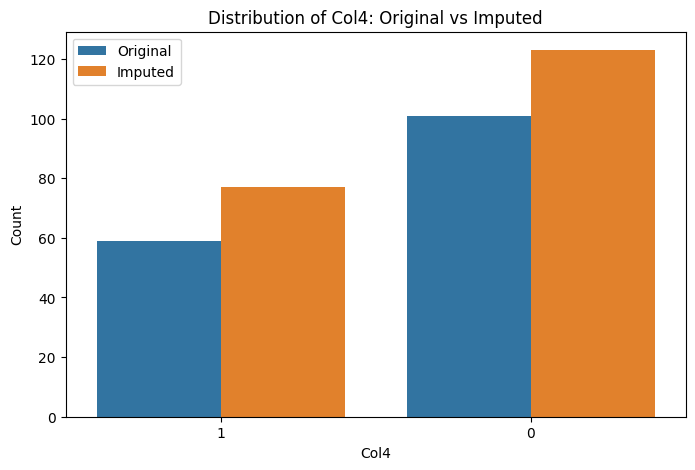

In [7]:
# Distribution of Col4, with type ColType.BINARY

fig_dist, ax_dist, imputed_df = plot_imputation_distribution(data, missing_col="Col4", missing_col_type=ColType.BINARY,
                                                             random_state=DEFAULT_RANDOM_STATE, display_plot=True)

In the following example, the dataset `data_categ_non_num` will be used to show how a categorical non-numeric column, `block_col`, will have its values imputed. In fact, the distribution plot automatically switches to a count plot for categorical and binary data.

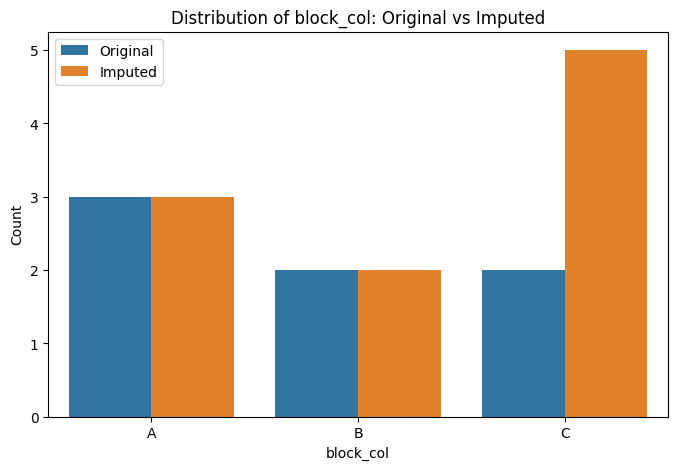

In [8]:
fig_categ, ax_categ, categ_imputed_df = plot_imputation_distribution(data_categ_non_num, missing_col="block_col", 
                                                                         missing_col_type=ColType.DISC_CATEGORICAL,
                                                                         random_state=DEFAULT_RANDOM_STATE, display_plot=True)

For columns of `ColType.DISCRETE` data type, `plot_imputation_distribution()` uses a `histplot`, instead of `KDE` or `countplot`.

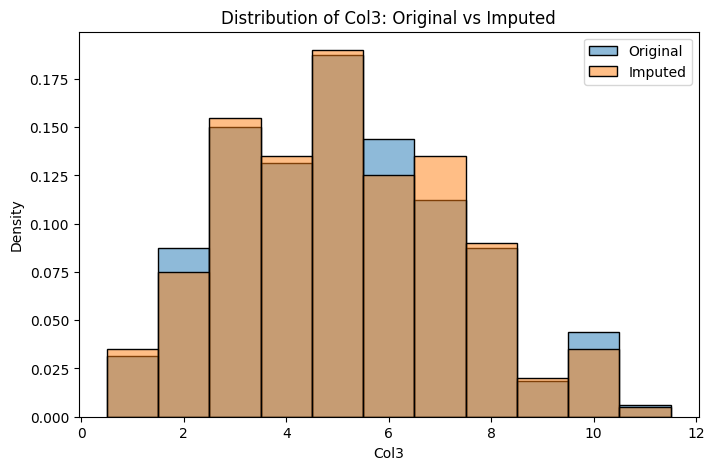

In [9]:
fig_disc, ax_disc, imputed_disc_df = plot_imputation_distribution(data, missing_col="Col3", missing_col_type=ColType.DISCRETE,
                                                                  random_state=DEFAULT_RANDOM_STATE, display_plot=True)